In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np                        
import matplotlib.pyplot as plt           

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

In [4]:
AAPL_df = pd.read_csv("AAPL_historical_data.csv")

AAPL_df.head(10)

,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-10-01,139.136673,142.649994,142.919998,139.110001,141.899994,94639600
1,2021-10-04,135.713120,139.139999,142.210007,138.270004,141.759995,98322000
2,2021-10-05,137.634628,141.110001,142.240005,139.360001,139.490005,80861100
3,2021-10-06,138.502716,142.000000,142.149994,138.369995,139.470001,83221100
4,2021-10-07,139.760910,143.289993,144.220001,142.720001,143.059998,61732700
5,2021-10-08,139.380539,142.899994,144.179993,142.559998,144.029999,58773200
6,2021-10-11,139.292725,142.809998,144.809998,141.809998,142.270004,64452200
7,2021-10-12,138.024780,141.509995,143.250000,141.039993,143.229996,73035900
8,2021-10-13,137.439545,140.910004,141.399994,139.199997,141.240005,78762700
9,2021-10-14,140.219345,143.759995,143.880005,141.509995,142.110001,69907100


In [5]:
AAPL_df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000,1.254000e+03
mean,202.613590,204.591228,206.634761,202.336962,204.354880,6.357783e+07
std,51.261960,50.366183,50.775127,49.893761,50.294542,2.855109e+07
min,122.827606,125.019997,127.769997,124.169998,126.010002,1.791060e+07
25%,162.922287,166.140003,167.872498,164.590000,166.092499,4.489712e+07
50%,189.051575,191.264999,192.620003,189.700005,190.959999,5.517040e+07
75%,234.510593,236.359997,238.145000,233.420002,235.509995,7.514605e+07
max,341.070007,341.070007,345.339996,338.750000,341.079987,3.186799e+08


In [6]:
AAPL_df.shape

(1254, 7)

followed the 5(a) loading method

In [7]:
AAPL_df = pd.read_csv("AAPL_historical_data.csv", parse_dates = ['Date'], index_col = 'Date')

In [8]:
AAPL_df.head(10)

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2021-10-01,139.136673,142.649994,142.919998,139.110001,141.899994,94639600
2021-10-04,135.713120,139.139999,142.210007,138.270004,141.759995,98322000
2021-10-05,137.634628,141.110001,142.240005,139.360001,139.490005,80861100
2021-10-06,138.502716,142.000000,142.149994,138.369995,139.470001,83221100
2021-10-07,139.760910,143.289993,144.220001,142.720001,143.059998,61732700
2021-10-08,139.380539,142.899994,144.179993,142.559998,144.029999,58773200
2021-10-11,139.292725,142.809998,144.809998,141.809998,142.270004,64452200
2021-10-12,138.024780,141.509995,143.250000,141.039993,143.229996,73035900
2021-10-13,137.439545,140.910004,141.399994,139.199997,141.240005,78762700


In [9]:
# Drop null values from the dataframe
AAPL_df = AAPL_df.dropna()

# Display the sumof null values
AAPL_df.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [10]:
AAPL_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1254 entries, 2021-10-01 to 2026-09-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1254 non-null   float64
 1   Close      1254 non-null   float64
 2   High       1254 non-null   float64
 3   Low        1254 non-null   float64
 4   Open       1254 non-null   float64
 5   Volume     1254 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.6 KB


Adapted from Tutorial 6(a)

In [11]:
# plotds is method to plot time series, ACF and PACF
def plotds(xt, nlag = 30, fig_size = (12, 10)):            # Function to plot time series, ACF, and PACF
    if not isinstance(xt, pd.Series):                      # Check if input is not a pandas Series
         xt = pd.Series(xt)                                # Convert input to pandas Series if needed
         
    plt.figure(figsize = fig_size)                         # Create a figure with specified size
    layout = (2, 2)                                        # Define grid layout (2 rows x 2 columns)
    
    ax_xt = plt.subplot2grid(layout, (0, 0), colspan = 2)  # Top plot spans both columns (time series)
    ax_acf= plt.subplot2grid(layout, (1, 0))               # Bottom-left plot for ACF
    ax_pacf = plt.subplot2grid(layout, (1, 1))             # Bottom-right plot for PACF
    
    xt.plot(ax = ax_xt)                                    # Plot the time series data
    ax_xt.set_title('Time Series')                         # Set title for time series plot
    
    plot_acf(xt, lags = nlag, ax = ax_acf)                   # Plot autocorrelation function (ACF)
    plot_pacf(xt, lags = nlag, ax = ax_pacf)                 # Plot partial autocorrelation function (PACF)
    
    plt.tight_layout()                                     # Adjust layout to prevent overlapping
    return None                                            # Function returns nothing

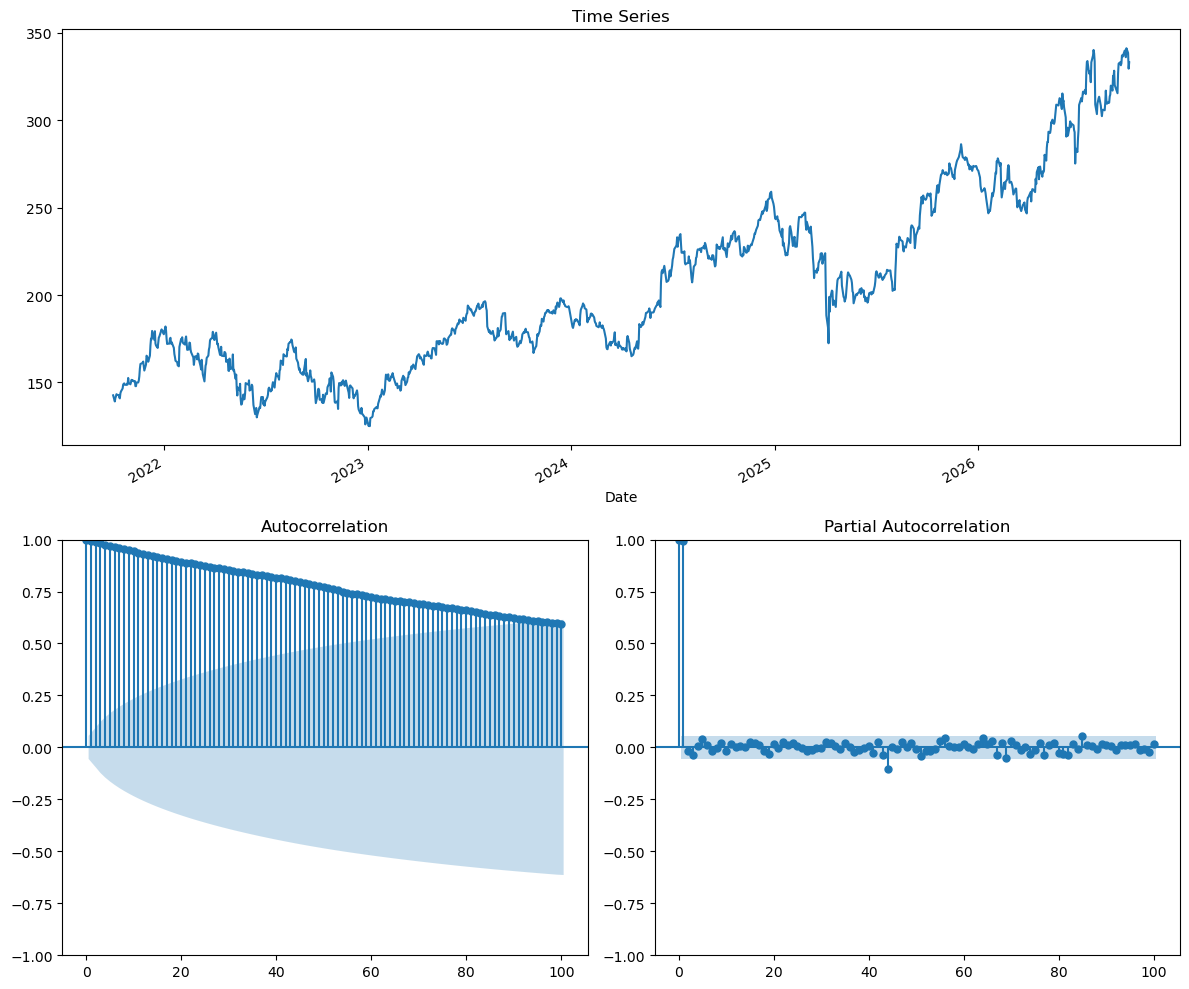

In [12]:
# Display plot of close column and Date index
plotds(AAPL_df['Close'], nlag = 100)

In [13]:
# Row position of the middle of the dataset, used to divide the series into two equal halves
mid = len(AAPL_df) // 2

# Calculate the mean value of first half and second half
mean1, mean2 = AAPL_df.iloc[:mid].Close.mean(), AAPL_df.iloc[mid:].Close.mean()

# Calculate the variance value of  first half and second half
var1, var2 = AAPL_df.iloc[:mid].Close.var(), AAPL_df.iloc[mid:].Close.var()

# Display mean and variance of two parts of the time series
print('mean1 = %f, mean2 = %f' % (mean1, mean2))
print('variance1 = %f, variance2 = %f' % (var1, var2))

mean1 = 164.875439, mean2 = 244.307017
variance1 = 306.218870, variance2 = 1611.610899


In [14]:
from statsmodels.tsa.stattools import adfuller

# Call adfuller() function to calculate the values
adf_result = adfuller(AAPL_df.Close.tolist())
print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])

ADF Statistic: -0.389084
p-value: 0.911905


p = 0.91 > 0.05 so the series is non-stationary so differencing is needed

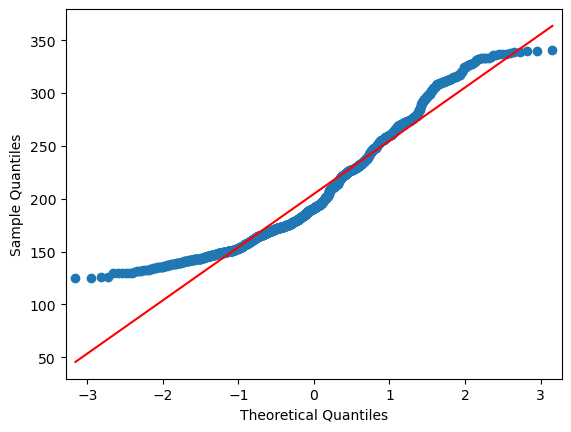

In [15]:
import statsmodels.api as sm

# qqplot for the 'Close' column : help us to understand normal distribution or not
x = sm.qqplot(AAPL_df['Close'], line = 's')

The points are not following the red line at the beginning and at the end, so the Close prices are not normally distributed

In [16]:
# Store one difference value of the 'Close' column
first_order_diff = AAPL_df['Close'].diff(1)

# Display the first five records
first_order_diff.head()

Date
2021-10-01         NaN
2021-10-04   -3.509995
2021-10-05    1.970001
2021-10-06    0.889999
2021-10-07    1.289993
Name: Close, dtype: float64

In [17]:
# Remove the first row because it is empty (NaN)
first_order_diff = AAPL_df['Close'].diff(1).dropna()

# Display the first five records
first_order_diff.head()

Date
2021-10-04   -3.509995
2021-10-05    1.970001
2021-10-06    0.889999
2021-10-07    1.289993
2021-10-08   -0.389999
Name: Close, dtype: float64

Text(0.5, 1.0, 'First-order differences of AAPL during Oct 2021-Sep 2026')

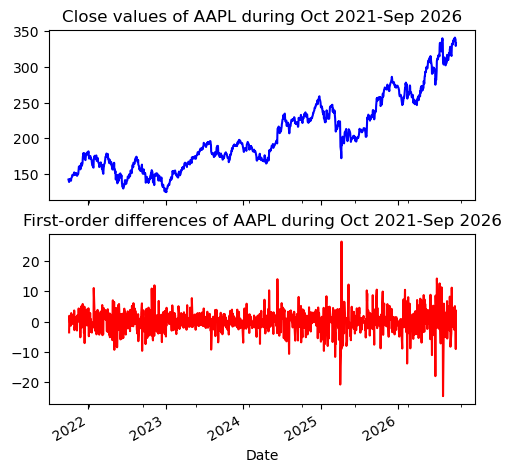

In [18]:
# Declare the fig and ax as two arguments 
fig, ax = plt.subplots(2, sharex = True)
fig.set_size_inches(5.5, 5.5)
AAPL_df['Close'].plot(ax = ax[0], color = 'b')
ax[0].set_title('Close values of AAPL during Oct 2021-Sep 2026')
first_order_diff.plot(ax = ax[1], color = 'r')
ax[1].set_title('First-order differences of AAPL during Oct 2021-Sep 2026')

ADF Statistic: -33.730495
p-value: 0.000000


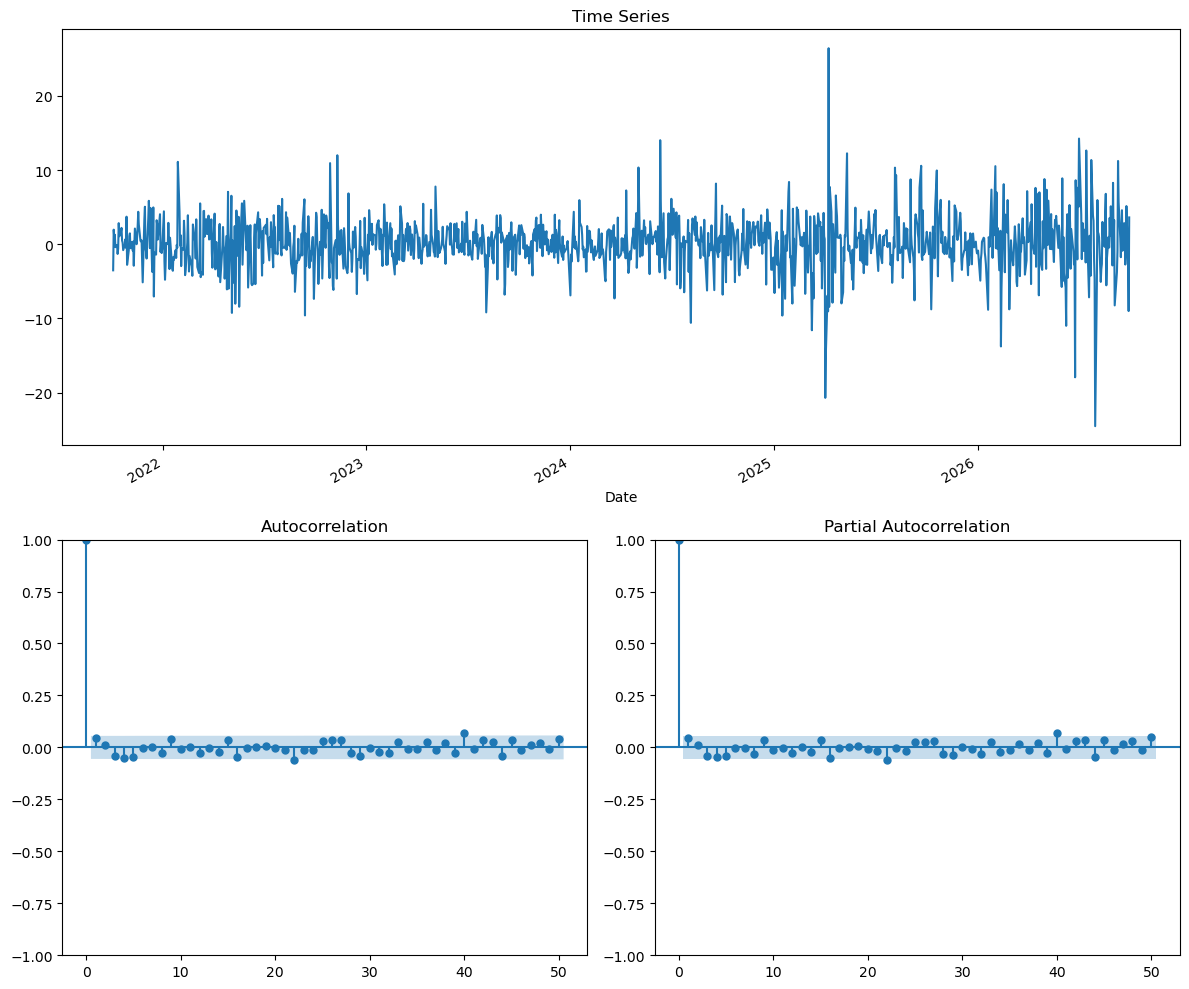

In [19]:
# plot the data with 50 lags
plotds(first_order_diff, nlag = 50)

# Perform Dicky Fuller test
adf_result = adfuller(first_order_diff)

# Display the outcomes
print('ADF Statistic: %f' % adf_result[0])
print('p-value: %f' % adf_result[1])

ADF test: p = 0.000 < 0.05, so the differenced series is stationary. One difference was enough, so d = 1

ACF and PACF have no clear spikes after lag 0, so this suggests p = 0 and q = 0, which I'll check with AIC.

This followed tutorial 5a

My dataset has 1254 rows for 5 years, so 1254 / 5 ≈ 251 rows per year. This is close to 252, the usual number of trading days in one year, so I chose 252 as the period

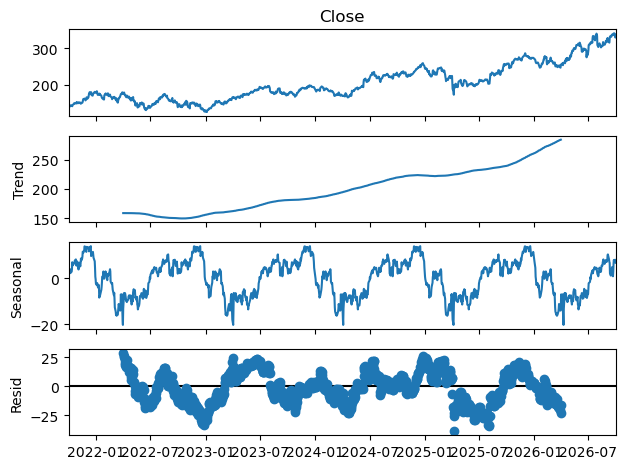

seasonal_var= 62.626331, resid_var= 175.418045


In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

# decompose the data using seasonal_decompose() function
decomposition = seasonal_decompose(AAPL_df['Close'], period = 252, model = 'additive')

# Plot the function using plot()
decomposition.plot()
plt.show()
print("seasonal_var= %f, resid_var= %f" % (decomposition.seasonal.var(), decomposition.resid.var()))

The trend is going up from about 150 to above 250, which is what I conclude from the graph. 

The seasonality is not strong, because the residual variance (about 175) is bigger than the seasonal variance (about 63).

I'll use ARIMA and not SARIMA, because my data has a trend but weak seasonality.


Adapted from Tutorial 6(a) : d is fixed at 1 because the ADF test showed one difference is enough

In [21]:
from statsmodels.tsa.arima.model import ARIMA
# A nested loop is written to calculate the AIC values
aicVal = []                                      # Initialize an empty list to store ARIMA parameters and AIC values

for ari in range(0, 3):                       # Loop over AR terms (p = 0 to 2)
    for maj in range(0, 3):                   # Loop over MA terms (q = 0 to 2)
        try:
            arima_obj = ARIMA(AAPL_df['Close'].tolist(), order=(ari, 1, maj))  # Create ARIMA model with parameters (p=ari, d=1, q=maj)                
            arima_obj_fit = arima_obj.fit()                                    # Fit the ARIMA model to the data                
            aicVal.append([ari, 1, maj, float(arima_obj_fit.aic)])             # Store p, d, q values along with the computed AIC
        except ValueError:                                                     # Handle cases where model fails to fit
            pass                                                               # Ignore errors and continue loop

# Print results line by line
for val in aicVal:                                                                 # Loop through stored AIC results
    print(val)                                                                     # Print each combination of (p, d, q) and its AIC value

[0, 1, 0, 6737.42389701669]
[0, 1, 1, 6736.5311230479865]
[0, 1, 2, 6738.043402474042]
[1, 1, 0, 6736.439025111846]
[1, 1, 1, 6738.366554645381]
[1, 1, 2, 6738.070304079203]
[2, 1, 0, 6738.229460696244]
[2, 1, 1, 6739.746674416303]
[2, 1, 2, 6736.561632697776]


In [22]:
# Find the minimum AIC value and corresponding model
best_model = min(aicVal, key=lambda x: x[3])
print(f"\nMinimum AIC value: {best_model[3]:.2f}")
print(f"Best model: ARIMA({best_model[0]}, {best_model[1]}, {best_model[2]})")


Minimum AIC value: 6736.44
Best model: ARIMA(1, 1, 0)


The best model is ARIMA(1,1,0), with the lowest AIC of 6736.44.

The lowest AIC (6736.44) and the highest (6739.75) differ by only about 3 points, so the nine models are almost the same.

ARIMA(0,1,0), the model suggested by the ACF and PACF, has an AIC of 6737.42. This is just 1 point higher than the best model, so they are almost the same.

Adapted from Tutorial 6(b): the model is tested on data has never seen 

In [23]:
# split the data into 85% for training and 15% for testing
train = AAPL_df[:int(0.85 * (len(AAPL_df)))]
test  = AAPL_df[int(0.85 * (len(AAPL_df))):]

train.shape, test.shape

((1065, 6), (189, 6))

Adapted from Tutorial 6(a): I fit ARIMA(1,1,0), which had the lowest AIC, on the training data only (the first 85%).

In [24]:
# Declare and initialise an object 'arima_obj' by calling a method 'ARIMA()'
arima_obj = ARIMA(train['Close'].tolist(), order = (1, 1, 0))

# d = 1
# Train the ARIMA model by calling a method fit()
arima_obj_fit = arima_obj.fit()


# Display the summary of the trained model
arima_obj_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1065
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -2764.522
Date:                Thu, 08 Oct 2026   AIC                           5533.043
Time:                        16:31:59   BIC                           5542.983
Sample:                             0   HQIC                          5536.810
                               - 1065                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0505      0.019      2.697      0.007       0.014       0.087
sigma2        10.5758      0.224     47.120      0.000      10.136      11.016
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2203.12
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.55   Skew:                             0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.03
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

The p-value of ar.L1 is 0.007 < 0.05, so the AR term is significant, but its coefficient is only 0.05, so the effect is small.

Ljung-Box: Prob(Q) = 0.95 > 0.05, so there is no pattern left in the errors (residuals). This is a good result.

Prob(JB) and Prob(H) are 0.00, below 0.05, and the kurtosis is 10, so the errors are not normally distributed. The extreme days come from the big spikes in 2025 and 2026

adapted from Tutorial 6(b).

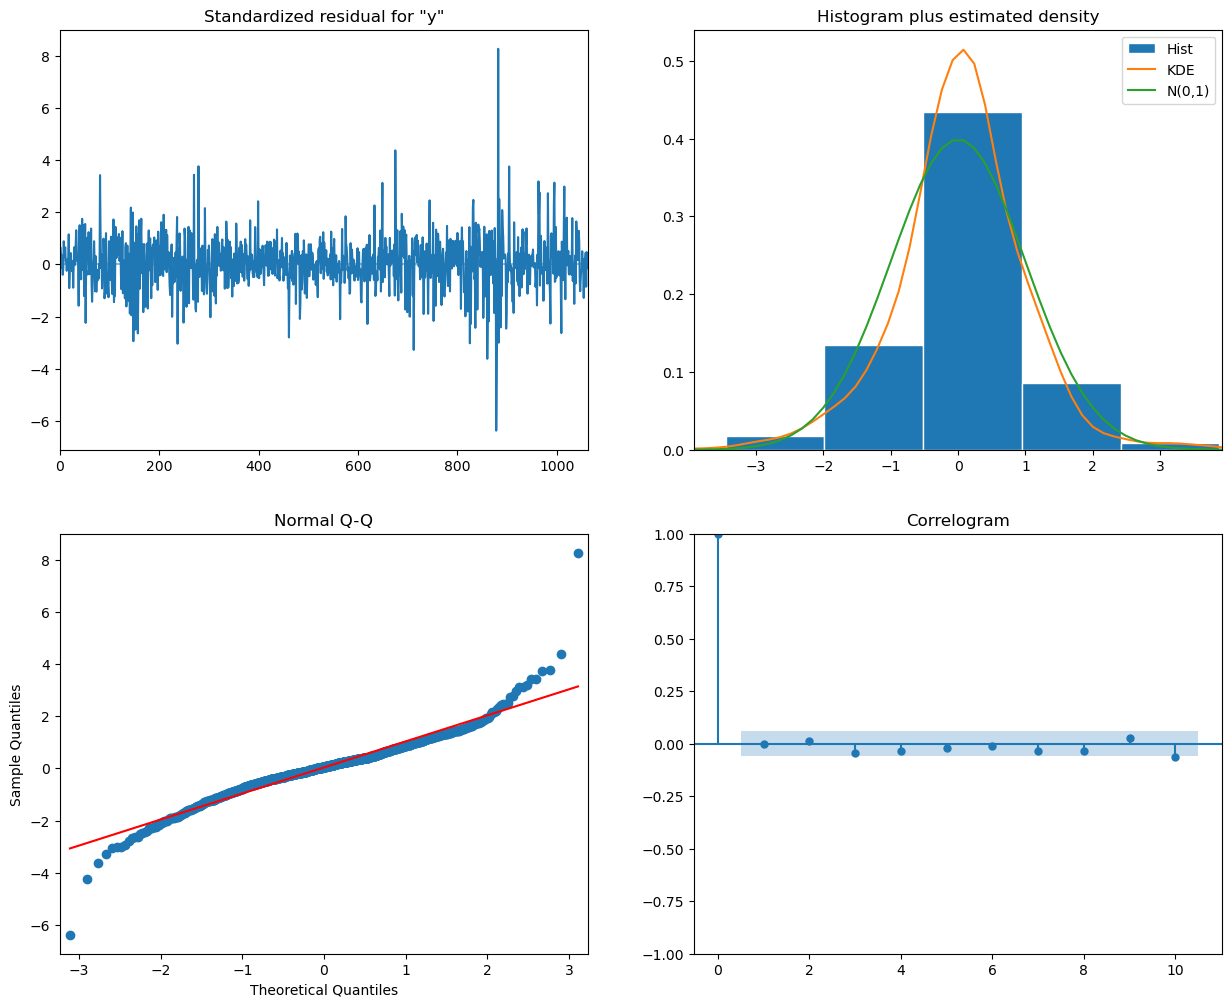

In [25]:
# Diagnosing the model residuals
arima_obj_fit.plot_diagnostics(figsize = (15, 12))
plt.show()

resid is adapted from Tutorial 6(a), and argmax/argmin from the Comparison of Performance Indexes notebook

In [26]:
# This cell finds the rows with the biggest positive error and the biggest negative error
max_row = np.argmax(arima_obj_fit.resid[1:]) + 1
min_row = np.argmin(arima_obj_fit.resid[1:]) + 1

print(max_row, train.index[max_row])
print(min_row, train.index[min_row])

883 2025-04-09 00:00:00
879 2025-04-03 00:00:00


No pattern is left, which is really good, because all the errors are around 0 and the bars are inside the band

The orange line doesn't match the green one, and the dots leave the red line at both ends, which means the errors aren't normally distributed.

The biggest errors happened at row 883 (9 April 2025) and row 879 (3 April 2025), which are the big spikes

The moves here were sudden and far larger than usual, which explains why the model couldn't predict these days.

adapted from Tutorial 6(a) : it forecasts the test period, 189 days, with a 95% confidence interval

In [27]:
# number of days to forecast = size of the test set
steps = len(test)

result = arima_obj_fit.get_forecast(steps = steps)
forecast = result.predicted_mean
ci_95 = result.conf_int(alpha = 0.05)

In [29]:
# Add the forecast and the 95% confidence limits to the test table
test['ARIMA_forecast'] = forecast
test['lower_95'] = ci_95[:, 0]
test['upper_95'] = ci_95[:, 1]

test.head()

,Adj Close,Close,High,Low,Open,Volume,ARIMA_forecast,lower_95,upper_95
Date,,,,,,,,,
2025-12-30,272.338684,273.079987,274.079987,272.279999,272.809998,22139600,273.778184,267.404291,280.152078
2025-12-31,271.122009,271.859985,273.679993,271.750000,273.059998,27293600,273.779102,264.534728,283.023476
2026-01-02,270.274353,271.010010,277.839996,269.000000,272.260010,37838100,273.779148,262.355130,285.203166
2026-01-05,266.534546,267.260010,271.510010,266.140015,270.640015,45647200,273.779151,260.528908,287.029393
2026-01-06,261.647797,262.359985,267.549988,262.119995,267.000000,52352100,273.779151,258.925524,288.632777


adapted from Tutorial 7(b) (the train, test and forecast lines) and 6(a) (the confidence band) : it shows the forecast against the real prices

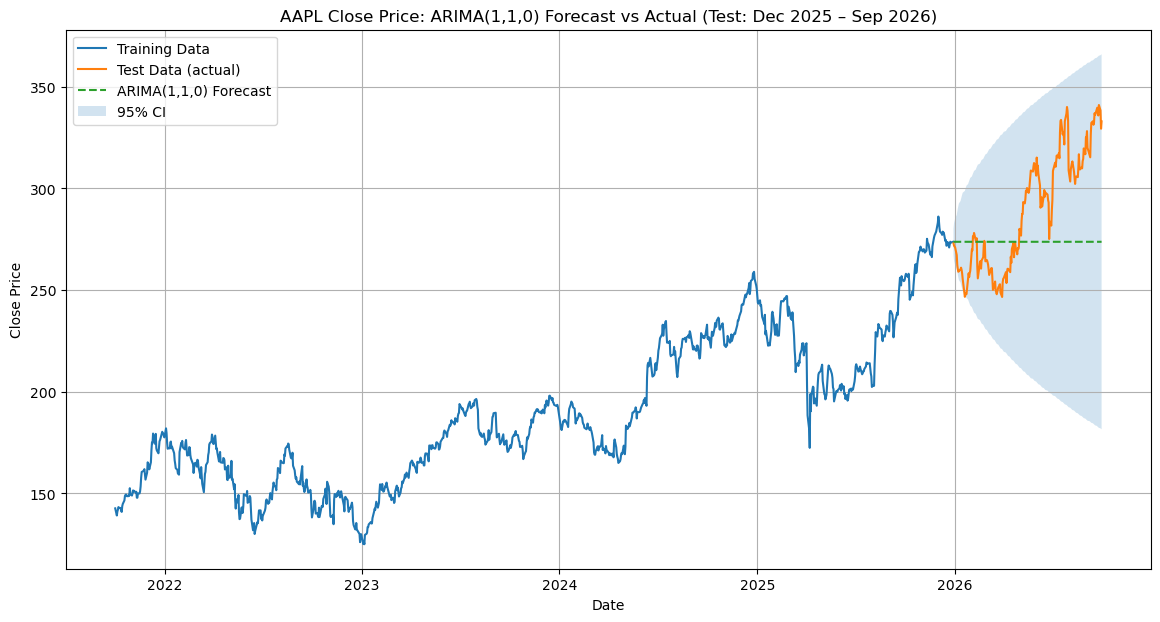

In [31]:
plt.figure(figsize = (14, 7))

plt.plot(train.index, train['Close'], label = 'Training Data')
plt.plot(test.index, test['Close'], label = 'Test Data (actual)')
plt.plot(test.index, test['ARIMA_forecast'], label = 'ARIMA(1,1,0) Forecast', linestyle = '--')

plt.fill_between(test.index, test['lower_95'], test['upper_95'], alpha = 0.2, label = '95% CI')

plt.title('AAPL Close Price: ARIMA(1,1,0) Forecast vs Actual (Test: Dec 2025 – Sep 2026)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend(loc = 'best')
plt.grid(True)
plt.show()

In [32]:
# Baseline: repeat the last training price for every test day
last = train['Close'].iloc[-1]
test.loc[:, 'pred_last'] = last

In [33]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ARIMA errors
mae_arima  = mean_absolute_error(test['Close'], test['ARIMA_forecast'])
rmse_arima = np.sqrt(mean_squared_error(test['Close'], test['ARIMA_forecast']))
mape_arima = mape(test['Close'], test['ARIMA_forecast'])

# Baseline errors
mae_last  = mean_absolute_error(test['Close'], test['pred_last'])
rmse_last = np.sqrt(mean_squared_error(test['Close'], test['pred_last']))
mape_last = mape(test['Close'], test['pred_last'])

print('ARIMA    -> MAE:', mae_arima, ' RMSE:', rmse_arima, ' MAPE:', mape_arima)
print('Baseline -> MAE:', mae_last,  ' RMSE:', rmse_last,  ' MAPE:', mape_last)

ARIMA    -> MAE: 26.605434156036658  RMSE: 32.314646877293654  MAPE: 8.783275610322848
Baseline -> MAE: 26.608781602647568  RMSE: 32.323949458734  MAPE: 8.783884226121975


On average, the ARIMA forecast was about $26.6 away from the real price (MAE), which is about 8.8% (MAPE).
    
The baseline (last known price) gave almost the same errors: MAE 26.6 and MAPE 8.8%.
    
This shows that ARIMA is not better than the baseline, because AAPL’s daily price changes are close to random (a random walk)